In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy


# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [3]:
from scipy.interpolate import make_interp_spline, CubicSpline

w0 = -0.75
wa = -0.86

def w_of_z(z, z_i, w_i):
    """
    Returns the equation of state as a function of redshift.

    Outside the knot range, w is held constant at the endpoint values:
    w_i[0] for z < z_i[0] and w_i[-1] for z > z_i[-1].
    """
    z = np.asarray(z)
    #spl_i = make_interp_spline(z_i, w_i)
    spl_i = CubicSpline(z_i, w_i)
    return spl_i(np.clip(z, z_i[0], z_i[-1]))
    #return spl_i(z)

def w_of_z_cpl(z, w0, wa):
    z = np.asarray(z)
    return w0 + wa * z / (1.0 + z)

zs = np.linspace(1e-4, 2.2, 100)
zdesi = [0.295, 0.51, 0.706, 0.93, 1.317, 1.491]
zeuclid_spectro = [0.97, 1.27, 1.63]
zeuclid_photo = [0.4371, 0.726, 0.9242, 1.164, 1.437, 1.963]

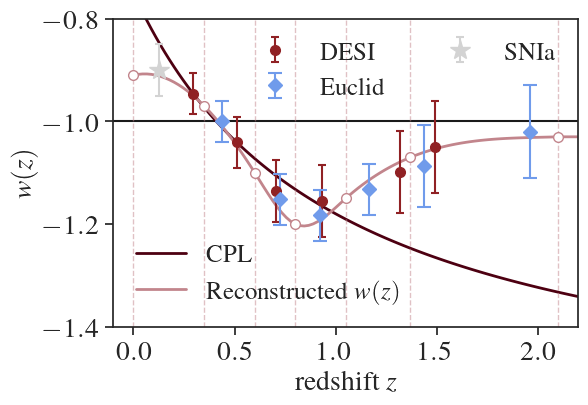

In [4]:
from matplotlib import rc
rc('text', usetex=True)
rc('font', **{'family': 'serif', 'serif': ['Times']})
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)
# Create two-panel figure with power spectra and ratios
colors = [#'#902124', '#C2858C', 
    '#4D0011', '#709BEB', '#C2858C', 'lightgray'
           ]
i = 5
fig, ax = plt.subplots(figsize=(6, 4))
desi_wz = [w_of_z_cpl(zdesi[0], w0, wa), w_of_z_cpl(zdesi[1], w0, wa), w_of_z_cpl(zdesi[2], w0, wa)-0.03, 
w_of_z_cpl(zdesi[3], w0, wa)+0.01, w_of_z_cpl(zdesi[4], w0, wa)+0.14,  -1.05]
# euclid_wz = [w_of_z_cpl(zeuclid_spectro[0], w0, wa)+0.04, w_of_z_cpl(zeuclid_spectro[1], w0, wa)+0.13,  -1.03]

wz_euclid_photo = [-1, w_of_z_cpl(zeuclid_photo[1], w0, wa)-0.04, 
w_of_z_cpl(zeuclid_photo[2], w0, wa)-0.02, 
w_of_z_cpl(zeuclid_photo[3], w0, wa)+0.08, w_of_z_cpl(zeuclid_photo[4], w0, wa)+0.17, -1.02]
z_bins = [0., 0.35, 0.6, 0.8, 1.05, 1.37, 2.1]#1.7]            
w_bins = [-0.91, -0.97, -1.1,  -1.2,  -1.15, -1.07, -1.03]
ax.axhline(-1, color='k', linestyle='-', linewidth=1.5)    
ax.plot(zs, w_of_z_cpl(zs, w0, wa), label='CPL', color=colors[0], lw=2)        
ax.plot(zs, w_of_z(zs, z_bins, w_bins), color=colors[2], lw=2, label=r'Reconstructed $w(z)$')
# data_handle = ax.errorbar(
#                 zeuclid_spectro,
#                 euclid_wz,
#                 yerr=0.08*np.ones(len(zeuclid_spectro)),#error_desi,
#                 color=colors[1],
#                 marker='o',
#                 #markerfacecolor='none',
#                 #markeredgecolor=colors[1],
#                 linestyle='none',
#                 capsize=3,
#                 capthick=1.5,
#                 elinewidth=1.5,
#                 label='Euclid'
#             )
error_desi = [0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
desi_handle = ax.errorbar(
                zdesi,
                desi_wz,
                yerr=error_desi,
                color='#902124',
                marker='o',
                markersize=7,
                #markerfacecolor='none',
                #markeredgecolor='#902124',
                linestyle='none',
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
                label='DESI'
            )
error_euclid = [0.04, 0.05, 0.05, 0.05, 0.08, 0.09]
euclid_handle = ax.errorbar(
                zeuclid_photo,
                wz_euclid_photo,
                yerr=error_euclid,
                color=colors[1],
                marker='D',
                #markerfacecolor='none',
                #markeredgecolor=colors[1],
                linestyle='none',
                markersize=7,
                capsize=5,
                capthick=1.5,
                elinewidth=1.5,
                label='Euclid'
            )
ax.errorbar( [0.125],
                [-0.9],
                yerr=[0.05],#error_desi,
                color='lightgray',
                marker='*',
                #markerfacecolor='none',
                #markeredgecolor='#902124',
                linestyle='none',
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
                markersize=15,
                label='SNIa'
            )

for i in range(len(z_bins)):
    ax.axvline(z_bins[i], ls='--', color=colors[2], lw=1, alpha=0.5)
data_handle = ax.errorbar(
                z_bins,
                w_bins,
                color=colors[2],
                marker='o',
                markerfacecolor='white',
                markeredgecolor=colors[2],
                linestyle='none',
                markersize=7,
                # capsize=5,
                # capthick=1.5,
                # elinewidth=1.5,
            )

# ax.set_xscale('log')
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(-1.4, -0.8)
# # Get all handles and labels
handles, labels = ax.get_legend_handles_labels()
# # Separate "Data" from other labels
main_handles = []
main_labels = []
data_handle_legend = []
data_handle_labels = []
for handle, label in zip(handles, labels):
    if label in ['SNIa', 'DESI', 'Euclid']:
        data_handle_legend.append(handle)
        data_handle_labels.append(label)
    else:
        main_handles.append(handle)
        main_labels.append(label)
# Create main legend first and add it as an artist (so it persists)
main_legend = ax.legend(main_handles, main_labels, loc='lower left', frameon=False, ncol=1)
ax.add_artist(main_legend)
# Create separate legend for Data in upper right corner
if data_handle_legend is not None:
    ax.legend(data_handle_legend, data_handle_labels, loc='upper right', frameon=False, ncol=2)
ax.set_xlabel("redshift $z$")
ax.set_ylabel(r"$w(z)$")
plt.savefig('w_of_z_proposal.png', dpi=300, bbox_inches='tight')  